## Number Recognition by PyTorch

### Preparation

In [13]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np

torch.manual_seed(0)

function for plotting

In [18]:
def PlotParameters(model):
    W = model.state_dict()['linear.weight'].data
    w_min = W.min().item()
    w_max = W.max().item()
    fig, axes = plt.subplots(2, 5)
    fig.subplots_adjust(hspace=0.01, wspace=0.1)
    for i, ax in enumerate(axes.flat):
        if i < 10:

            # Set the label for the sub-plot.
            ax.set_xlabel("class: {0}".format(i))

            # Plot the image.
            ax.imshow(W[i, :].view(28, 28), vmin=w_min, vmax=w_max, cmap='seismic')

            ax.set_xticks([])
            ax.set_yticks([])

        # Ensure the plot is shown correctly with multiple plots
        # in a single Notebook cell.
    plt.show()

In [19]:
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(28, 28), cmap='gray')
    plt.title('y = ' + str(data_sample[1]))

### 1. Data Load and Augment

注意： transform=transforms.ToTensor() 会把图像转为数字

In [14]:
train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
print("Print the training dataset:\n ", train_dataset)

Print the training dataset:
  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [15]:
validation_dataset = dsets.MNIST(root='./data', download=True, transform=transforms.ToTensor())
print("Print the validating dataset:\n ", validation_dataset)

Print the validating dataset:
  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [16]:
print("Type of data element: ", type(train_dataset[0][1]))

Type of data element:  <class 'int'>


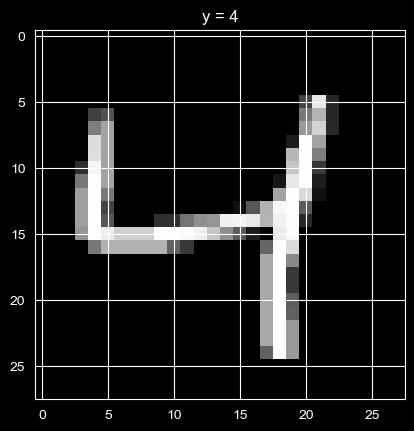

In [20]:
show_data(train_dataset[2])

In [21]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

### 2. Model Definition



In [27]:
class  SoftMax(nn.Module):
    def __init__(self, in_features, out_features):
        super(SoftMax, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
    def forward(self, x):
        return self.linear(x)

In [23]:
input_dim = 28 * 28
output_dim = 10

In [28]:
model = SoftMax(input_dim, output_dim)
print("Print the model:\n ", model)

Print the model:
  SoftMax(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


- 结果输出10个类别，在模型中就对应有10个线性方程
- 图像为28*28，转成784向量，因此每个线性方程有784个w和1个b

In [34]:
print('W: ',list(model.parameters())[0].size())
print('b: ',list(model.parameters())[1].size())

W:  torch.Size([10, 784])
b:  torch.Size([10])


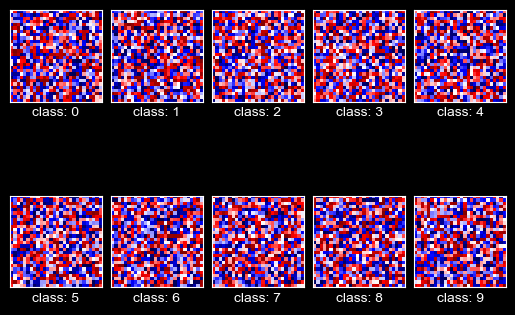

In [35]:
PlotParameters(model)

### 3. Training Configuration

🤔思考： 既然是多分类， 为什么不直接使用softmax而是使用nn.CrossEntropyLoss()
- 核心原因：数学上的“数值稳定性” (Numerical Stability)
- Softmax 函数包含指数运算 $e^{z_k}$。当你的 Logits（线性层输出的 $z$）非常大时，$e^{z}$ 会迅速爆炸，导致计算机内存溢出（Overflow）。
- nn.CrossEntropyLoss() 的黑科技：它在内部将 LogSoftmax 和 NLLLoss（负对数似然损失）合并了。
- Log-Sum-Exp 技巧：它使用了一种数学上的技巧，直接计算 $\log(\text{Softmax})$，从而避免了中间步骤出现巨大的指数值。这保证了模型训练时不会因为数值太大而崩溃。

数学上，nn.CrossEntropyLoss() 等同于以下两个步骤的组合：
1. LogSoftmax: 先对输入的原始得分（Logits）进行 Softmax，然后再取对数 $\log$。
2. NLLLoss (Negative Log Likelihood Loss): 负对数似然损失，用来衡量预测概率分布与真实标签之间的差距。$$\text{CrossEntropyLoss} = \text{LogSoftmax} + \text{NLLLoss}$$

In [38]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

### 4. Training Loop

#### Flatten Input Images to 1D vectors
思考： 为什么使用x.view(-1, 28*28) 将图像转1D向量

In [39]:
n_epochs = 10
loss_list = []
accuracy_list = []
N_test = len(validation_dataset)
N_train = len(train_dataset)

def train_model(n_epochs):
    for epoch in range(n_epochs):
        for epoch in range(n_epochs):
            model.train() # 明确设置为训练模式
            total_loss = 0
            for x, y in train_loader:
                optimizer.zero_grad()
                output = model(x.view(-1, 28 * 28))
                loss = criterion(output, y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            correct = 0
            model.eval()
            with torch.no_grad(): # 省内在
                for xt, yt in validation_dataset:
                    z = model(xt.view(-1, 28 * 28))
                    _, yhat = torch.max(z.data, 1)
                    correct += (yt == yhat).sum().item()
            accuracy = correct/N_test
            loss_list.append(total_loss/N_train)
            accuracy_list.append(accuracy)

In [40]:
train_model(n_epochs)

### 5. Model Evaluation

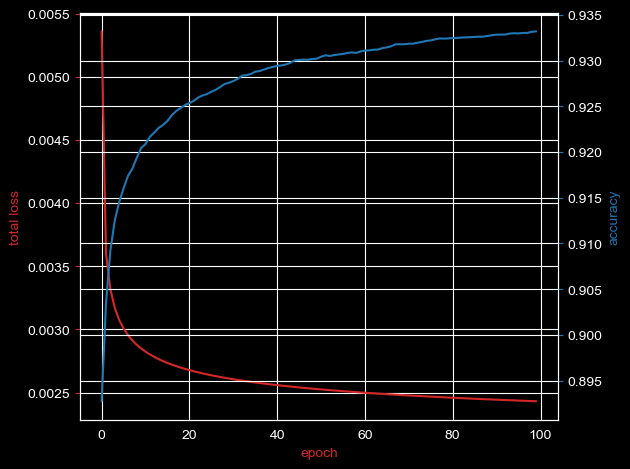

In [41]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(loss_list,color=color)
ax1.set_xlabel('epoch',color=color)
ax1.set_ylabel('total loss',color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

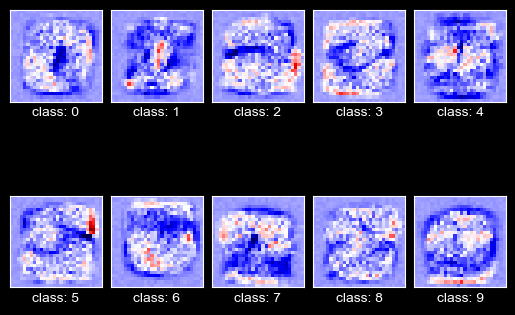

In [42]:
PlotParameters(model)

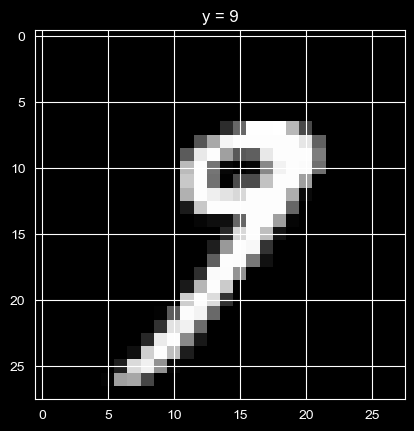

yhat: tensor([7])
probability of class  0.5091023445129395


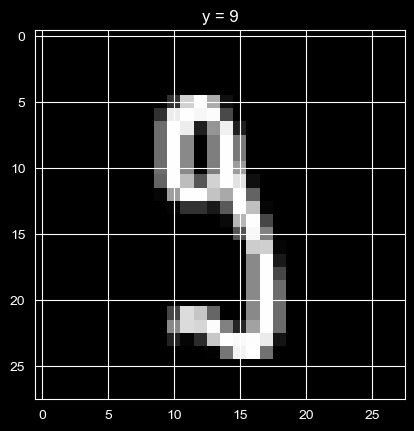

yhat: tensor([5])
probability of class  0.7173197865486145


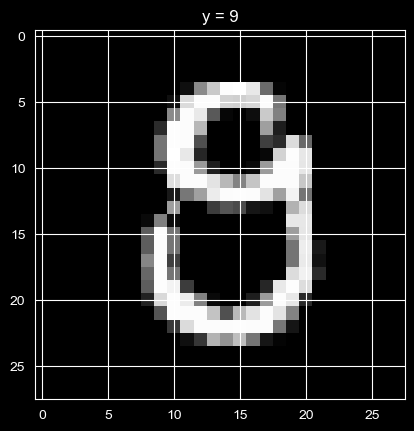

yhat: tensor([8])
probability of class  0.5812511444091797


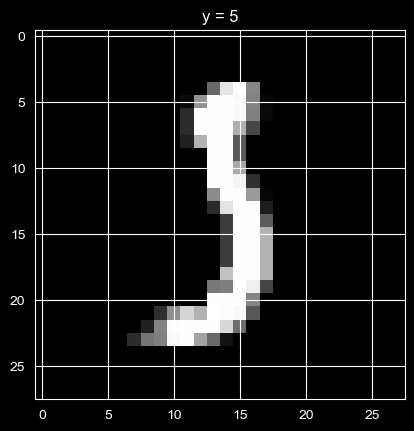

yhat: tensor([3])
probability of class  0.7819907069206238


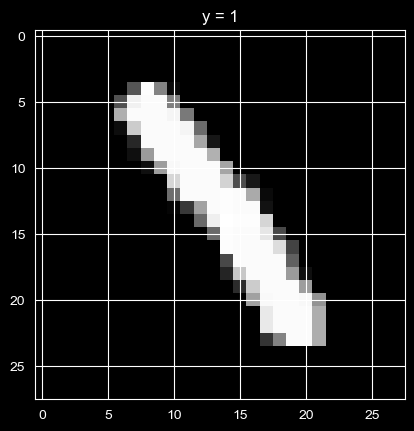

yhat: tensor([3])
probability of class  0.5044074654579163


In [43]:
# Plot the misclassified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat != y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break

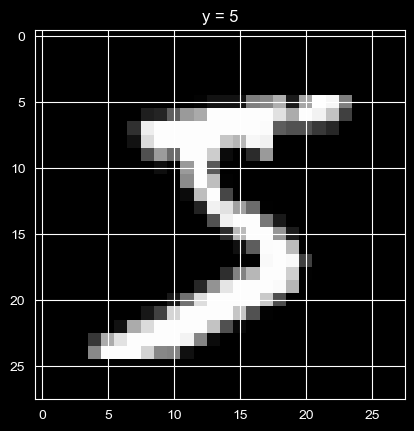

yhat: tensor([5])
probability of class  0.8447673916816711


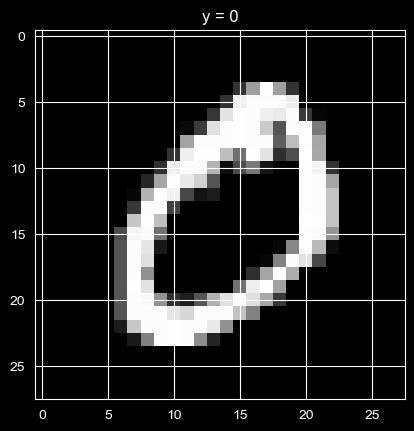

yhat: tensor([0])
probability of class  0.9999701976776123


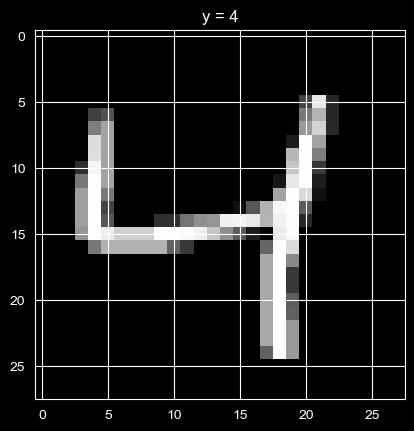

yhat: tensor([4])
probability of class  0.758898138999939


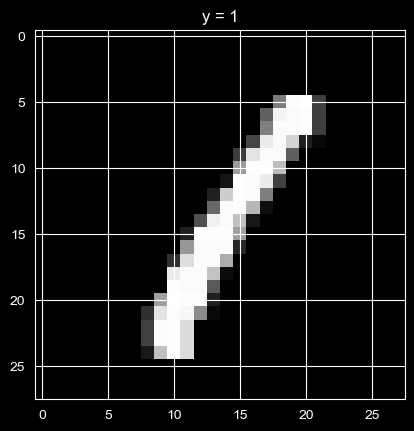

yhat: tensor([1])
probability of class  0.9732701778411865


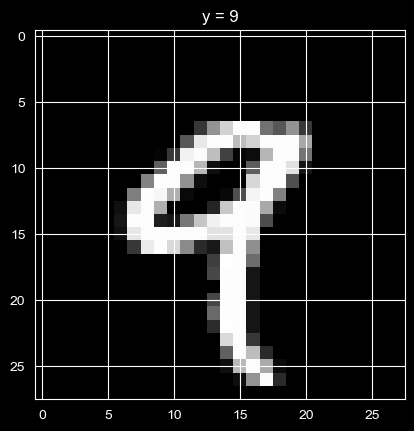

yhat: tensor([9])
probability of class  0.9582628607749939


In [44]:
# Plot the classified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat == y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break